# Loding Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [7]:
data = pd.read_csv("Dataset/amazon_enriched.csv")
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,return_rate_pct,demand_tier,is_seasonal_product,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr,first_sale_date,last_sale_date
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,3.83,High,False,464,616,224761.78,210876.15,-12231.10,2023-01-06,2025-12-28
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,6.24,High,False,346,479,88461.57,82552.87,9507.70,2023-01-01,2025-12-30
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,3.99,Medium,False,174,225,60616.08,54976.05,24489.41,2023-01-18,2025-12-25
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,7.45,High,False,487,633,193026.72,171559.00,10026.27,2023-01-01,2025-12-30
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,7.45,High,False,359,479,66653.00,58800.62,4640.54,2023-01-04,2025-12-30


# Clean Dataset

In [8]:
data.shape

(1465, 39)

In [9]:
data.describe()

,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,stock_quantity,avg_delivery_days,return_rate_pct,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1.465000e+03,1.465000e+03,1465.00000
mean,5446.219304,3125.439884,2538.617556,21.453195,435.941980,3.810922,4.973631,190.480546,252.509898,4.201019e+05,3.879582e+05,47681.49243
std,10874.374998,6944.274066,5935.119313,8.988895,262.710376,2.083081,1.428127,130.614243,173.385606,7.669658e+05,7.075901e+05,88188.27689
min,39.000000,39.000000,31.060000,6.000000,0.000000,1.000000,0.500000,12.000000,16.000000,3.515140e+03,3.128140e+03,-231326.62000
25%,800.000000,325.000000,260.500000,14.830000,210.000000,2.000000,4.020000,101.000000,135.000000,7.263678e+04,6.729155e+04,4285.68000
50%,1690.000000,799.000000,615.700000,19.370000,435.000000,4.000000,4.950000,158.000000,208.000000,1.758189e+05,1.625195e+05,15797.85000
75%,4295.000000,1999.000000,1586.420000,28.690000,660.000000,5.000000,5.880000,247.000000,325.000000,3.839057e+05,3.551768e+05,49889.07000
max,139900.000000,77990.000000,73218.570000,47.300000,899.000000,9.000000,10.660000,1072.000000,1418.000000,8.797807e+06,8.568651e+06,812315.86000


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   str    
 4   actual_price         1465 non-null   str    
 5   discount_percentage  1465 non-null   str    
 6   rating               1465 non-null   str    
 7   rating_count         1463 non-null   str    
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
 16 

In [11]:
# Drop unnecessary columns

text_cols = ["about_product", "review_content", "user_id", "img_link", "product_link"]

# keep product_id in both so you can rejoin later
text_df = data[["product_id"] + text_cols].copy()

data = data.drop(columns=text_cols)

In [12]:
data["discounted_price"] = data["discounted_price"].str.replace(r"[₹,]", "", regex=True).astype(float)

data["actual_price"] = data["actual_price"].str.replace(r"[₹,]", "", regex=True).astype(float)

data["discount_percentage"] = data["discount_percentage"].str.rstrip("%").astype(float) / 100

data["rating"] = pd.to_numeric(data["rating"], errors="coerce") 

data["rating_count"] = data["rating_count"].str.replace(",", "", regex=False).astype("Int64")

date_cols = ["launch_date", "first_sale_date", "last_sale_date"]
for c in date_cols:
    data[c] = pd.to_datetime(data[c], format="%Y-%m-%d", errors="coerce")



In [13]:
# Adding New column for future use

data["sale_span_days"]    = (data["last_sale_date"] - data["first_sale_date"]).dt.days
data["age_at_first_sale"] = (data["first_sale_date"] - data["launch_date"]).dt.days

In [14]:
# Spliting category

data[["cat_l1", "cat_l2", "cat_l3"]] = data["category"].str.split("|", expand=True).iloc[:, :3]

In [15]:
# Drop Null Value

data = data.dropna(subset=["rating", "rating_count", "cat_l3"])

print(data.isnull().sum()[lambda s: s > 0])

Series([], dtype: int64)


In [16]:
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,gross_revenue_inr,net_revenue_inr,total_profit_inr,first_sale_date,last_sale_date,sale_span_days,age_at_first_sale,cat_l1,cat_l2,cat_l3
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,224761.78,210876.15,-12231.10,2023-01-06,2025-12-28,1087,1302,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,88461.57,82552.87,9507.70,2023-01-01,2025-12-30,1094,1590,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,60616.08,54976.05,24489.41,2023-01-18,2025-12-25,1072,1753,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,193026.72,171559.00,10026.27,2023-01-01,2025-12-30,1094,1145,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,66653.00,58800.62,4640.54,2023-01-04,2025-12-30,1091,732,Computers&Accessories,Accessories&Peripherals,Cables&Accessories


# Feature engineering

In [17]:
data.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'user_name', 'review_id', 'review_title', 'brand', 'seller_id',
       'seller_name', 'main_category', 'launch_date', 'mrp_inr',
       'selling_price_inr', 'cost_price_inr', 'profit_margin_pct',
       'stock_quantity', 'warehouse_region', 'fulfilment_type',
       'avg_delivery_days', 'return_rate_pct', 'demand_tier',
       'is_seasonal_product', 'total_orders', 'total_units_sold',
       'gross_revenue_inr', 'net_revenue_inr', 'total_profit_inr',
       'first_sale_date', 'last_sale_date', 'sale_span_days',
       'age_at_first_sale', 'cat_l1', 'cat_l2', 'cat_l3'],
      dtype='str')

In [18]:
data['revenue_per_order'] = data.gross_revenue_inr / data.total_orders
data['units_per_order'] = data.total_units_sold / data.total_orders
data['sell_through'] = data.total_units_sold / (data.total_units_sold + data.stock_quantity)
data['active_days']=(data.last_sale_date - data.first_sale_date).dt.days.clip(lower=1)
data['units_per_day']=data.total_units_sold / data.active_days
data['product_age_days']=(pd.Timestamp('2026-09-20') - data.launch_date).dt.days
data['discount_depth']=(data.mrp_inr - data.selling_price_inr) / data.mrp_inr

data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,cat_l1,cat_l2,cat_l3,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,484.400388,1.327586,0.518519,1087,0.566697,2655,0.636943
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,255.669277,1.384393,0.460577,1094,0.437843,2948,0.429799
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,348.368276,1.293103,0.266272,1072,0.209888,3094,0.895208
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,396.358768,1.299795,0.489938,1094,0.578611,2503,0.529328
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,185.662953,1.334262,0.360693,1091,0.439047,2087,0.614035


In [19]:
data.describe().round(3)

,discounted_price,actual_price,discount_percentage,rating,rating_count,launch_date,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,...,last_sale_date,sale_span_days,age_at_first_sale,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
count,1454.000,1454.000,1454.000,1454.000,1454.0,1454,1454.000,1454.000,1454.000,1454.000,...,1454,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000
mean,3115.186,5430.478,0.477,4.095,18358.151,2020-05-11 03:04:12.544704,5431.716,3115.316,2529.815,21.479,...,2025-12-25 04:14:31.526822,1079.254,974.795,3950.122,1.324,0.404,1079.254,0.233,2322.872,0.477
min,39.000,39.000,0.000,2.000,2.0,2018-01-28 00:00:00,39.000,39.000,31.060,6.000,...,2025-09-01 00:00:00,802.000,122.000,49.483,1.000,0.024,802.000,0.017,1478.000,0.000
25%,325.000,800.000,0.320,4.000,1191.5,2019-02-28 06:00:00,800.000,325.000,261.270,14.830,...,2025-12-25 00:00:00,1077.000,548.250,392.082,1.286,0.226,1077.000,0.125,1889.250,0.321
50%,799.000,1670.000,0.500,4.100,5187.0,2020-06-16 12:00:00,1692.500,799.000,615.130,19.400,...,2025-12-28 00:00:00,1086.000,942.500,992.193,1.326,0.348,1086.000,0.193,2286.500,0.500
75%,1999.000,4295.000,0.630,4.300,17342.25,2021-07-18 18:00:00,4295.000,1999.000,1585.475,28.712,...,2025-12-30 00:00:00,1091.000,1416.000,2574.532,1.363,0.547,1091.000,0.298,2760.750,0.629
max,77990.000,139900.000,0.940,5.000,426973.0,2022-09-03 00:00:00,139900.000,77990.000,73218.570,47.300,...,2025-12-31 00:00:00,1095.000,1916.000,90699.045,1.600,1.000,1095.000,1.297,3157.000,0.941
std,6936.911,10869.620,0.216,0.290,42871.119,NaN,10869.166,6936.881,5928.603,9.000,...,NaN,22.754,485.861,8862.017,0.064,0.231,22.754,0.158,485.570,0.216


# EDA

### Distribution of prices

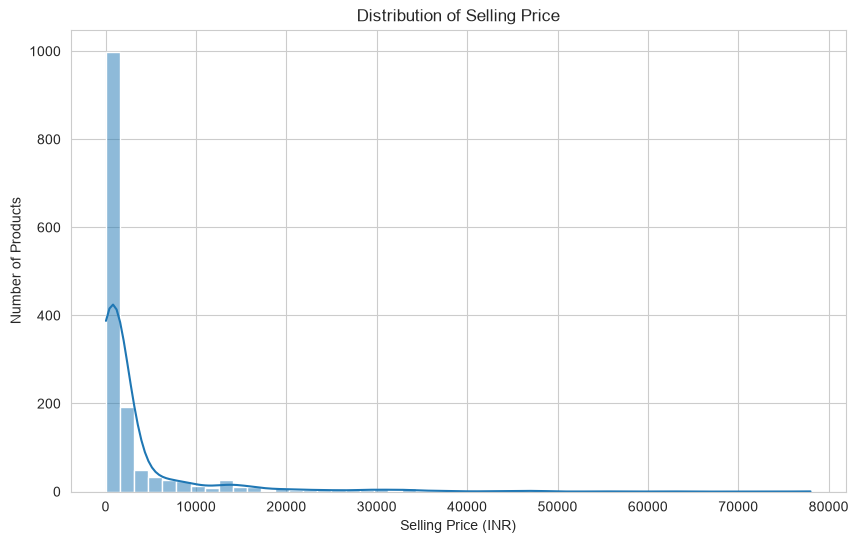

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['selling_price_inr'],
    bins=50,
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (INR)")
plt.ylabel("Number of Products")

plt.show()

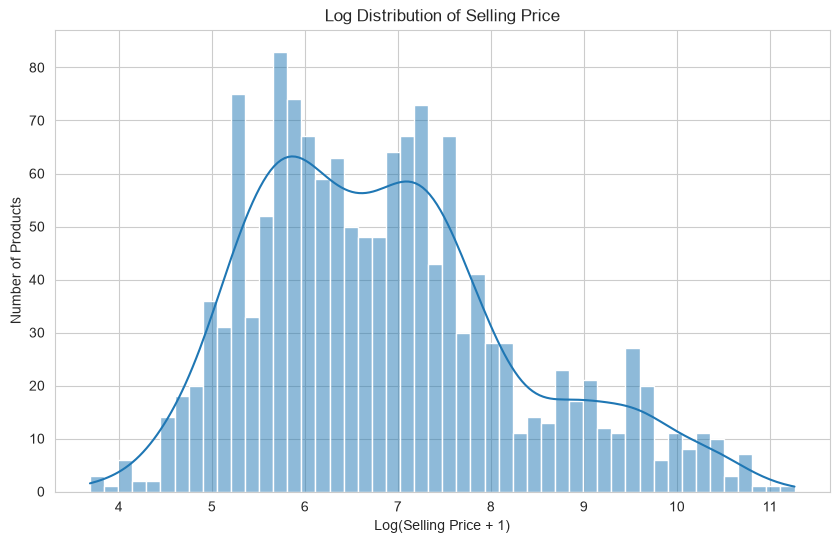

In [21]:
# Because prices are highly skewed, you can also use a log scale

plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(data['selling_price_inr']),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Selling Price")
plt.xlabel("Log(Selling Price + 1)")
plt.ylabel("Number of Products")

plt.show()

### Profit distribution

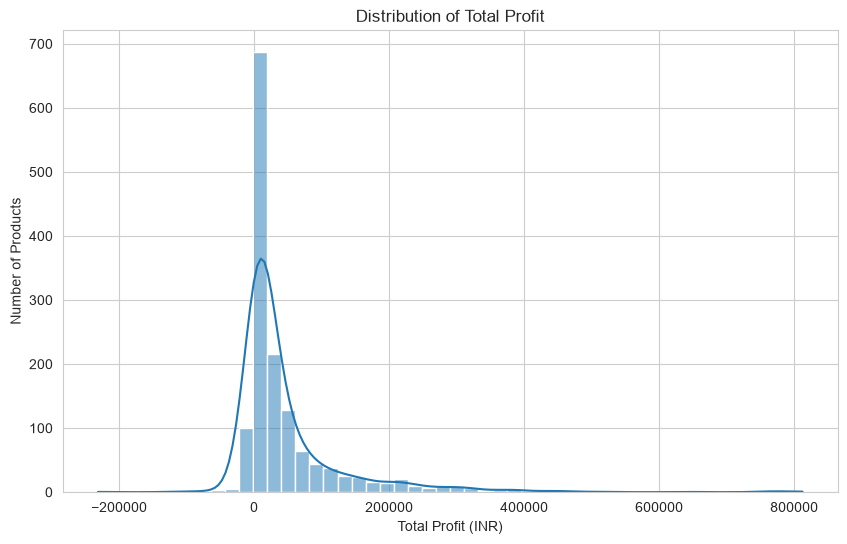

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['total_profit_inr'],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Profit")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Number of Products")

plt.show()

### Rating distribution

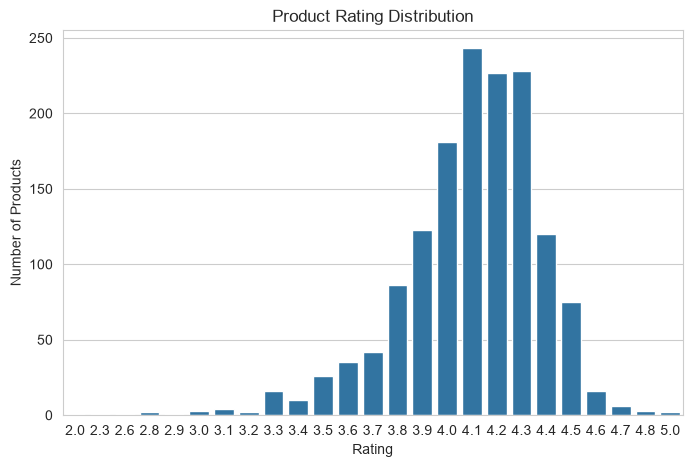

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='rating'
)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

### Discount analysis

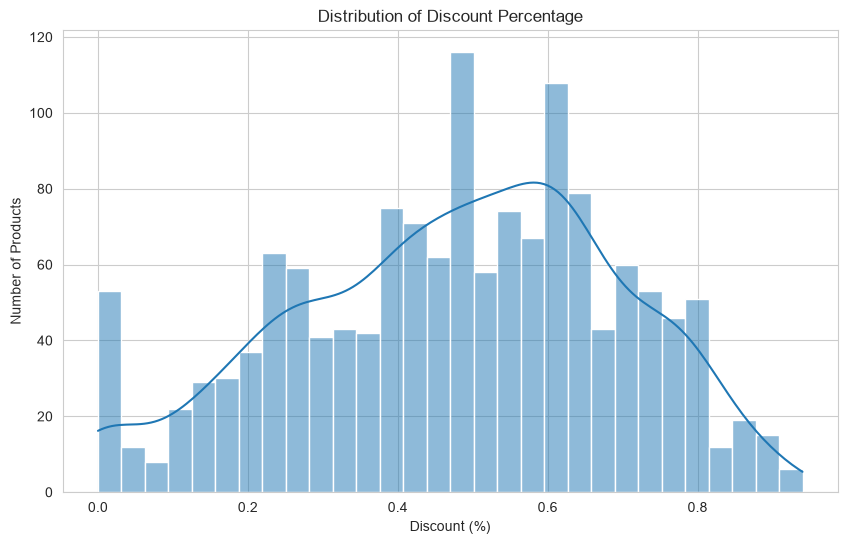

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['discount_percentage'],
    bins=30,
    kde=True
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")

plt.show()

### Profit margin distribution

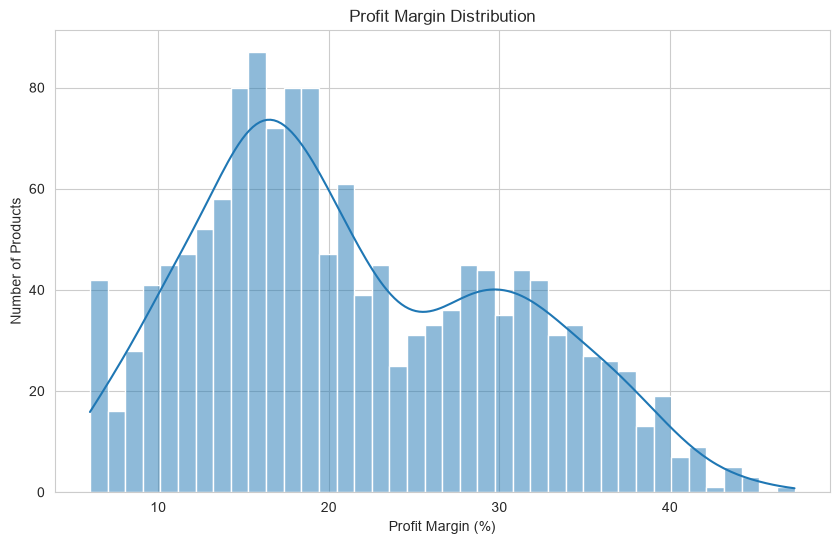

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['profit_margin_pct'],
    bins=40,
    kde=True
)

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Products")

plt.show()

### Correlation analysis

In [26]:
numeric_cols = [
    'mrp_inr',
    'selling_price_inr',
    'cost_price_inr',
    'profit_margin_pct',
    'stock_quantity',
    'avg_delivery_days',
    'return_rate_pct',
    'total_orders',
    'total_units_sold',
    'gross_revenue_inr',
    'net_revenue_inr',
    'total_profit_inr'
]

corr = data[numeric_cols].corr()

corr

,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,stock_quantity,avg_delivery_days,return_rate_pct,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr
mrp_inr,1.000000,0.961708,0.956784,-0.140707,0.034145,-0.033543,-0.038327,-0.293950,-0.292952,0.809969,0.812532,0.508276
selling_price_inr,0.961708,1.000000,0.995970,-0.134038,0.031367,-0.023269,-0.043933,-0.288976,-0.287957,0.861274,0.864071,0.553302
cost_price_inr,0.956784,0.995970,1.000000,-0.172840,0.027535,-0.020589,-0.040174,-0.275880,-0.274853,0.862628,0.866140,0.497786
profit_margin_pct,-0.140707,-0.134038,-0.172840,1.000000,0.017008,0.012723,-0.005973,-0.148478,-0.149086,-0.145411,-0.145962,0.267551
stock_quantity,0.034145,0.031367,0.027535,0.017008,1.000000,-0.006743,-0.032238,-0.002723,-0.003440,0.040842,0.039355,0.058046
avg_delivery_days,-0.033543,-0.023269,-0.020589,0.012723,-0.006743,1.000000,0.008690,0.047657,0.047818,-0.005682,-0.006618,-0.027380
return_rate_pct,-0.038327,-0.043933,-0.040174,-0.005973,-0.032238,0.008690,1.000000,-0.005907,-0.005948,-0.043687,-0.050309,-0.077596
total_orders,-0.293950,-0.288976,-0.275880,-0.148478,-0.002723,0.047657,-0.005907,1.000000,0.998476,-0.138857,-0.139569,-0.143290
total_units_sold,-0.292952,-0.287957,-0.274853,-0.149086,-0.003440,0.047818,-0.005948,0.998476,1.000000,-0.136988,-0.137548,-0.141021
gross_revenue_inr,0.809969,0.861274,0.862628,-0.145411,0.040842,-0.005682,-0.043687,-0.138857,-0.136988,1.000000,0.999068,0.660294


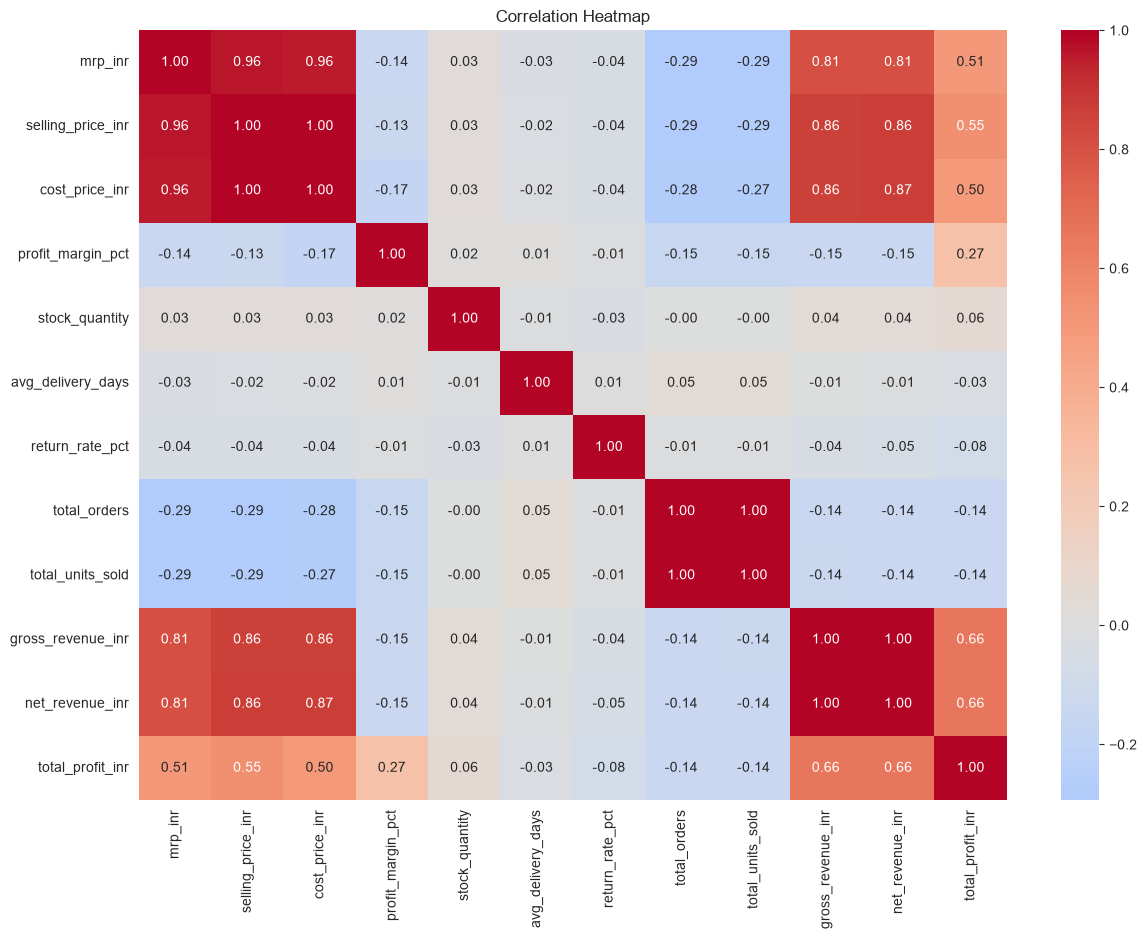

In [27]:
# Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

### Profit vs Revenue

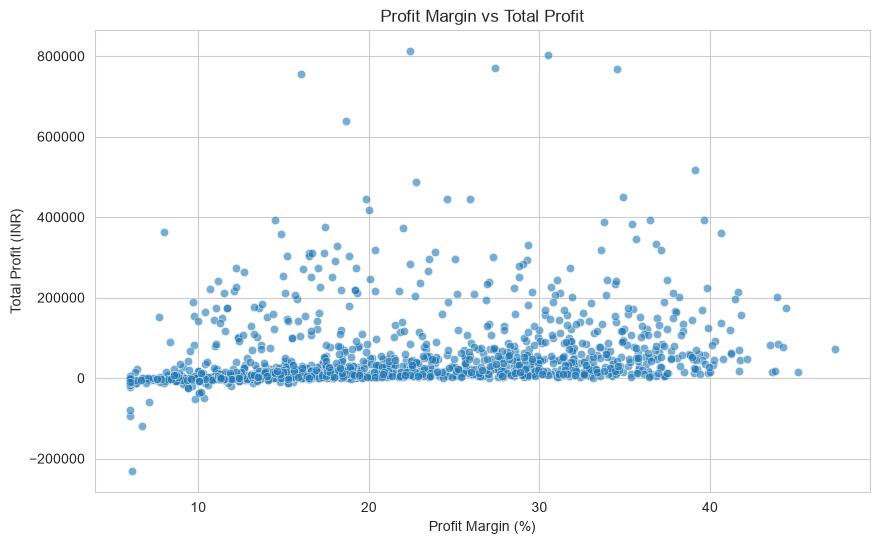

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='profit_margin_pct',
    y='total_profit_inr',
    alpha=0.6
)

plt.title("Profit Margin vs Total Profit")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Total Profit (INR)")

plt.show()

### Category-wise analysis

In [29]:
category_analysis = data.groupby('main_category').agg(
    products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    total_revenue=('net_revenue_inr', 'sum'),
    total_profit=('total_profit_inr', 'sum')
).sort_values(
    'total_profit',
    ascending=False
)

category_analysis

,products,avg_rating,total_revenue,total_profit
main_category,,,,
Home&Kitchen,447,4.040716,1.333723e+08,34956718.68
Electronics,522,4.079502,3.570980e+08,26307325.34
Computers&Accessories,447,4.154362,7.037908e+07,7352653.69
OfficeProducts,31,4.309677,2.436353e+06,589379.32
MusicalInstruments,2,3.900000,6.463169e+05,89373.38
Car&Motorbike,1,3.800000,2.310524e+05,48049.55
Health&PersonalCare,1,4.000000,1.439429e+05,41990.05
HomeImprovement,2,4.250000,1.796926e+05,29719.88
Toys&Games,1,4.300000,4.818846e+04,14598.90


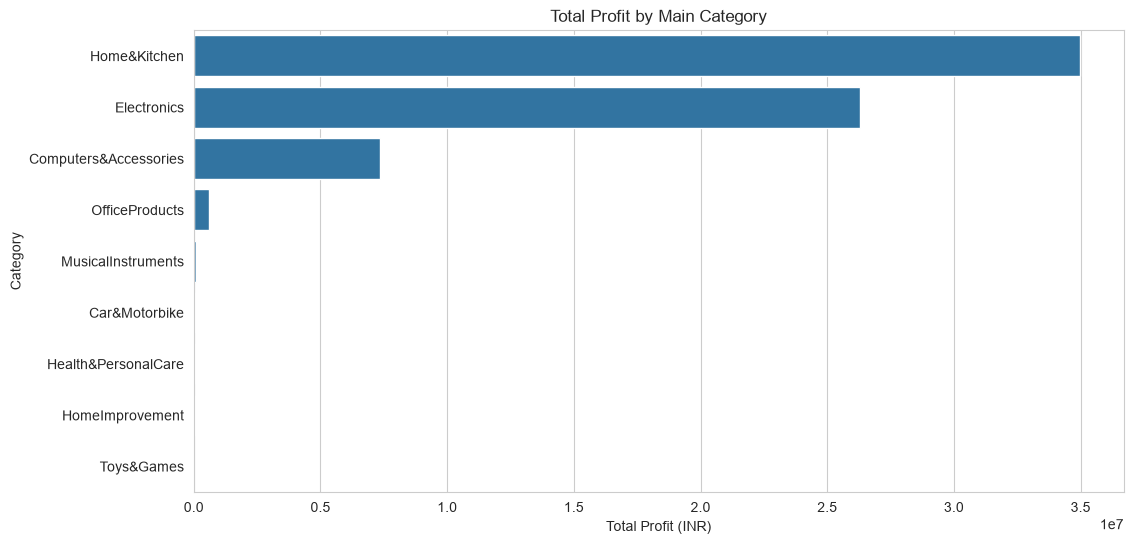

In [30]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_analysis.reset_index(),
    x='total_profit',
    y='main_category'
)

plt.title("Total Profit by Main Category")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Category")

plt.show()

### Top 10 brands by profit

In [31]:
brand_analysis = data.groupby('brand').agg(
    products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    total_revenue=('net_revenue_inr', 'sum'),
    total_profit=('total_profit_inr', 'sum')
).sort_values(
    'total_profit',
    ascending=False
)

top_brands = brand_analysis.head(10)

top_brands

,products,avg_rating,total_revenue,total_profit
brand,,,,
Redmi,26,4.053846,43151857.39,4123582.52
OnePlus,13,4.184615,43339801.61,3572103.26
Samsung,35,4.200000,46529690.48,3541424.58
Philips,18,4.261111,10215346.27,2905435.14
iQOO,14,4.157143,30929154.74,2396024.06
Bajaj,26,4.080769,8827892.92,2361717.95
Crompton,15,4.020000,6542668.89,1930145.75
MI,21,4.271429,22845726.11,1876655.30
LG,6,4.300000,13702820.12,1564507.19


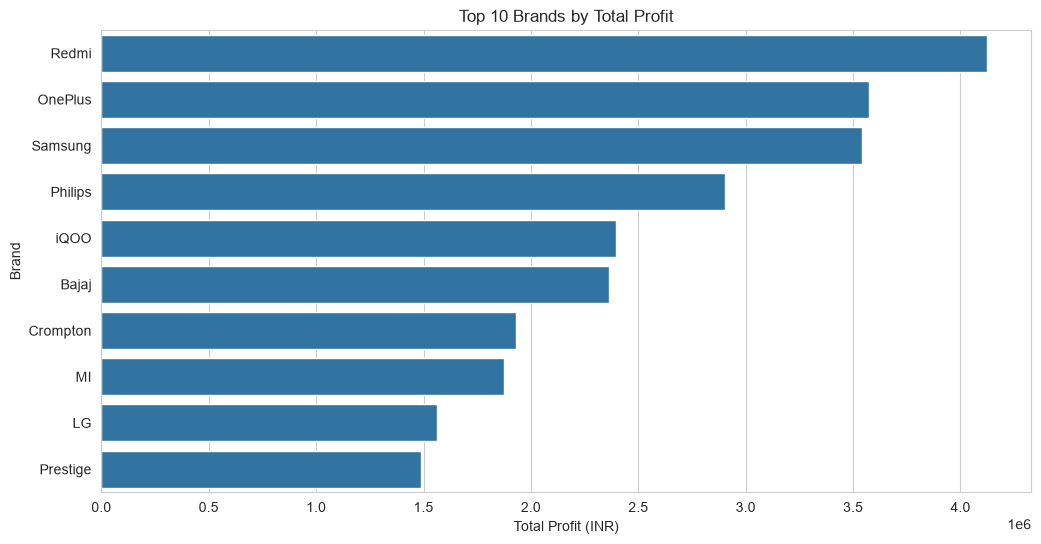

In [32]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_brands.reset_index(),
    x='total_profit',
    y='brand'
)

plt.title("Top 10 Brands by Total Profit")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Brand")

plt.show()

### Warehouse region analysis

In [33]:
region_analysis = data.groupby('warehouse_region').agg(
    products=('product_id', 'count'),
    orders=('total_orders', 'sum'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_delivery=('avg_delivery_days', 'mean')
).sort_values(
    'profit',
    ascending=False
)

region_analysis

,products,orders,revenue,profit,avg_delivery
warehouse_region,,,,,
South,398,75741,1.484060e+08,21119786.12,3.726131
North,360,66151,1.393721e+08,16546833.44,3.988889
West,332,65903,1.299453e+08,16249713.40,3.719880
East,220,42455,9.347943e+07,10511863.53,3.645455
Central,144,27172,5.333208e+07,5001612.30,4.006944


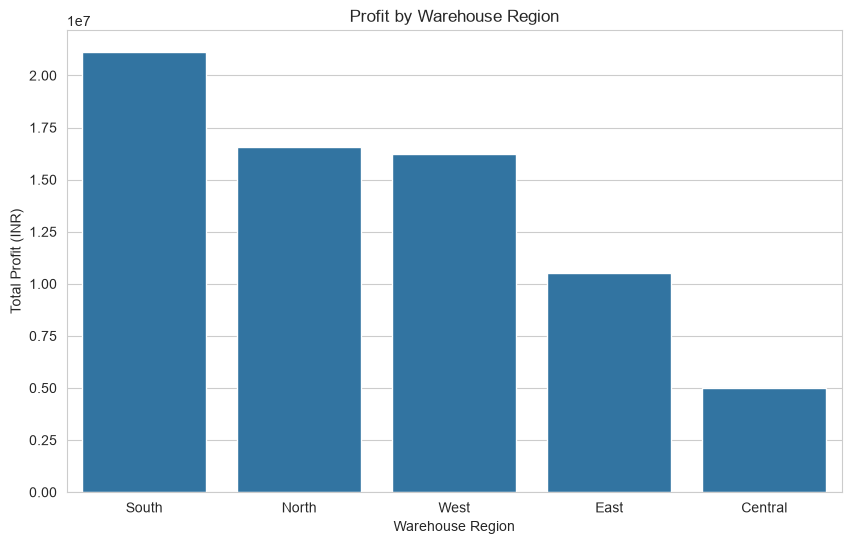

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis.reset_index(),
    x='warehouse_region',
    y='profit'
)

plt.title("Profit by Warehouse Region")
plt.xlabel("Warehouse Region")
plt.ylabel("Total Profit (INR)")

plt.show()

### Fulfilment type analysis

In [35]:
fulfilment_analysis = data.groupby('fulfilment_type').agg(
    products=('product_id', 'count'),
    orders=('total_orders', 'sum'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_delivery=('avg_delivery_days', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean')
)

fulfilment_analysis

,products,orders,revenue,profit,avg_delivery,avg_return_rate
fulfilment_type,,,,,,
FBA,727,140924,2.761421e+08,34441934.14,3.552957,4.915089
Prime,302,54558,1.149892e+08,14238267.83,1.470199,5.020629
Seller-Fulfilled,425,81940,1.734035e+08,20749606.82,5.896471,5.049012


### Seasonal products

In [36]:
seasonal_analysis = data.groupby('is_seasonal_product').agg(
    products=('product_id', 'count'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_rating=('rating', 'mean')
)

seasonal_analysis

,products,revenue,profit,avg_rating
is_seasonal_product,,,,
False,482,7.383674e+07,8121445.99,4.162241
True,972,4.906981e+08,61308362.80,4.062243


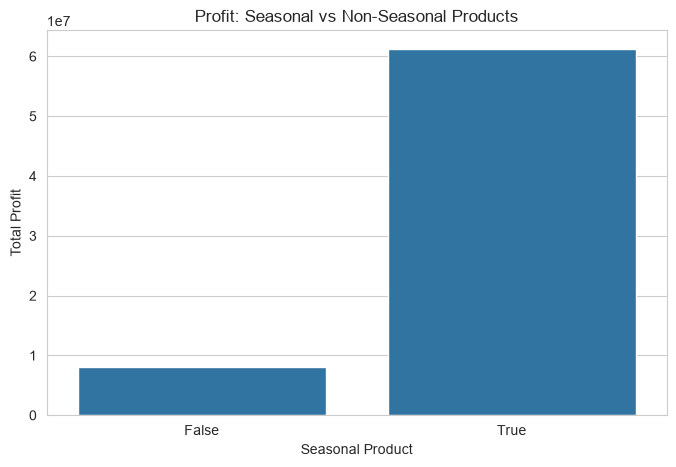

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_analysis.reset_index(),
    x='is_seasonal_product',
    y='profit'
)

plt.title("Profit: Seasonal vs Non-Seasonal Products")
plt.xlabel("Seasonal Product")
plt.ylabel("Total Profit")

plt.show()

### Outlier analysis

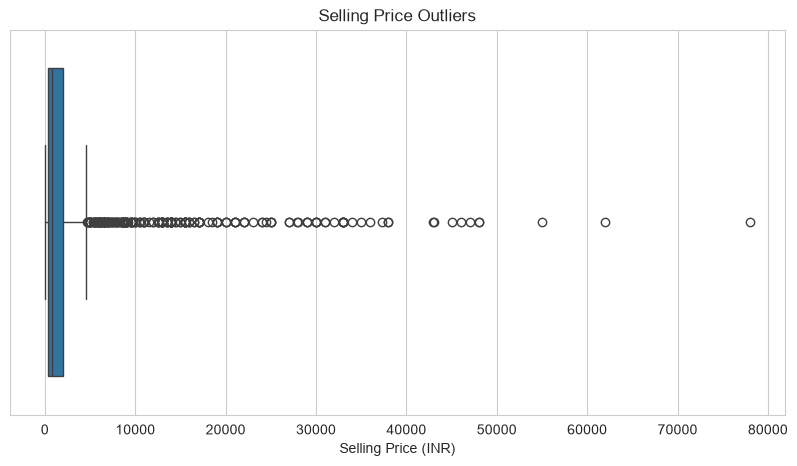

In [38]:
# Boxplot for selling price:

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=data['selling_price_inr']
)

plt.title("Selling Price Outliers")
plt.xlabel("Selling Price (INR)")

plt.show()

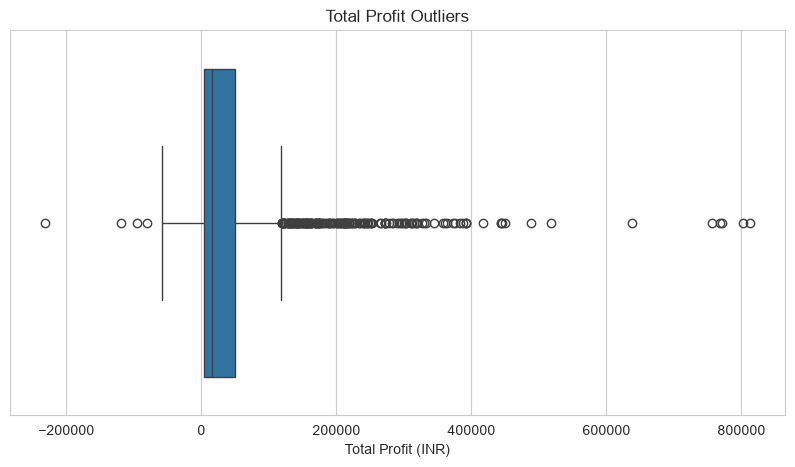

In [39]:
# Profit

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=data['total_profit_inr']
)

plt.title("Total Profit Outliers")
plt.xlabel("Total Profit (INR)")

plt.show()

### Top products by profit

In [40]:
top_products = data[
    [
        'product_name',
        'brand',
        'main_category',
        'selling_price_inr',
        'total_orders',
        'net_revenue_inr',
        'total_profit_inr'
    ]
].sort_values(
    'total_profit_inr',
    ascending=False
).head(10)

top_products

,product_name,brand,main_category,selling_price_inr,total_orders,net_revenue_inr,total_profit_inr
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,OnePlus,Electronics,32999.0,134,5131698.89,812315.86
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,LG,Home&Kitchen,42990.0,70,3488883.19,801677.74
1241,Usha Janome Dream Stitch Automatic Zig-Zag Ele...,Usha,Home&Kitchen,9799.0,273,3355272.06,771397.88
1297,AMERICAN MICRONIC- Imported Wet & Dry Vacuum C...,AMERICAN,Home&Kitchen,8886.0,236,2558139.70,768779.56
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,OnePlus,Electronics,61999.0,84,6406343.19,756617.51
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,MI,Electronics,46999.0,79,4397617.27,638596.61
1348,Crompton Solarium Qube 15-L 5 Star Rated Stora...,Crompton,Home&Kitchen,7799.0,174,1493866.25,517261.80
124,Redmi 126 cm (50 inches) 4K Ultra HD Android S...,Redmi,Electronics,32999.0,77,2774728.49,488296.96
1182,"Coway Professional Air Purifier for Home, Long...",Coway,Home&Kitchen,14400.0,125,1947402.91,449906.52
1306,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,ECOVACS,Home&Kitchen,27900.0,59,2148726.81,444667.47


### Top products by revenue

In [41]:
top_revenue_products = data[
    [
        'product_name',
        'brand',
        'main_category',
        'selling_price_inr',
        'total_orders',
        'net_revenue_inr',
        'total_profit_inr'
    ]
].sort_values(
    'net_revenue_inr',
    ascending=False
).head(10)

top_revenue_products

,product_name,brand,main_category,selling_price_inr,total_orders,net_revenue_inr,total_profit_inr
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Sony,Electronics,77990.0,97,8568651.16,-231326.62
216,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,OnePlus,Electronics,42999.0,127,6415008.80,151429.08
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,OnePlus,Electronics,61999.0,84,6406343.19,756617.51
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,OnePlus,Electronics,32999.0,134,5131698.89,812315.86
197,MI 108 cm (43 inches) 5A Series Full HD Smart ...,MI,Electronics,24999.0,162,4587727.41,272629.47
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,MI,Electronics,46999.0,79,4397617.27,638596.61
386,"OPPO A74 5G (Fantastic Purple,6GB RAM,128GB St...",OPPO,Electronics,15490.0,230,4367735.62,391922.68
533,"OnePlus 10T 5G (Moonstone Black, 8GB RAM, 128G...",OnePlus,Electronics,44999.0,79,4265509.65,222180.23
278,Mi 100 cm (40 inches) Horizon Edition Full HD ...,Mi,Electronics,21999.0,162,4022221.27,226578.24
410,"OnePlus 10R 5G (Forest Green, 8GB RAM, 128GB S...",OnePlus,Electronics,34999.0,86,3860319.74,154955.52


# Prediction model

In [42]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

### Select features

In [43]:
target = "total_units_sold"

features = [
    "selling_price_inr",
    "mrp_inr",
    "cost_price_inr",
    "discount_percentage",
    "rating",
    "rating_count",
    "profit_margin_pct",
    "stock_quantity",
    "avg_delivery_days",
    "return_rate_pct",
    "is_seasonal_product",
    "product_age_days",
    "warehouse_region",
    "fulfilment_type",
    "demand_tier",
    "main_category",
    "brand"
]

X = data[features].copy()
y = data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1454, 17)
y shape: (1454,)


### Train-test split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1163, 17)
Testing : (291, 17)


### Separate numerical and categorical features

In [45]:
numeric_features = X.select_dtypes(include=["int64", "float64", "Int64", "bool"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['selling_price_inr', 'mrp_inr', 'cost_price_inr', 'discount_percentage', 'rating', 'rating_count', 'profit_margin_pct', 'stock_quantity', 'avg_delivery_days', 'return_rate_pct', 'is_seasonal_product', 'product_age_days']
Categorical: ['warehouse_region', 'fulfilment_type', 'demand_tier', 'main_category', 'brand']


### Preprocessing

In [46]:
# For Linear/Ridge, scaling is useful.

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Evaluation function

In [47]:
def evaluate_model(name, model, X_test, y_test):
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### ML Models

In [48]:
#------------------Baseline--------------------------------------------------
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_result = evaluate_model( "Baseline", baseline, X_test, y_test)

#---------------Linear Regression--------------------------------------------
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_result = evaluate_model("Linear Regression", linear_model, X_test, y_test)

#---------------Ridge Regression--------------------------------------------
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_result = evaluate_model("Ridge Regression", ridge_model, X_test, y_test)

#---------------Random Forest--------------------------------------------
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result = evaluate_model("Random Forest", rf_model, X_test, y_test)

#---------------LightGBM-------------------------------------------------
lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_result = evaluate_model("LightGBM", lgbm_model, X_test, y_test)


Baseline
----------------------------------------
MAE  : 134.63
RMSE : 191.20
R²   : -0.0051

Linear Regression
----------------------------------------
MAE  : 110.59
RMSE : 154.82
R²   : 0.3410

Ridge Regression
----------------------------------------
MAE  : 105.78
RMSE : 145.77
R²   : 0.4158

Random Forest
----------------------------------------
MAE  : 73.76
RMSE : 108.37
R²   : 0.6771

LightGBM
----------------------------------------
MAE  : 77.77
RMSE : 115.53
R²   : 0.6330


### Compare all models

In [49]:
results = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    rf_result,
    lgbm_result
])

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Random Forest,73.755040,108.370812,0.677110
4,LightGBM,77.773430,115.532290,0.633025
2,Ridge Regression,105.775900,145.767621,0.415814
1,Linear Regression,110.592612,154.816383,0.341034
0,Baseline,134.629492,191.203691,-0.005129


### K-Fold Cross Validation

In [50]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []
for name, model in [("Baseline", baseline), ("Linear Regression", linear_model), ("Ridge Regression", ridge_model), ("Random Forest", rf_model), ("LightGBM", lgbm_model)]:
    cv_results = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV MAE":  -cv_results["test_MAE"].mean(),
        "MAE std":  cv_results["test_MAE"].std(),
        "CV RMSE": -cv_results["test_RMSE"].mean(),
        "CV R2":    cv_results["test_R2"].mean(),
        "R2 std":   cv_results["test_R2"].std(),
    })
    print(f"{name}: R² per fold -> {np.round(cv_results['test_R2'], 3)}")

pd.DataFrame(cv_rows).round(3)


Baseline: R² per fold -> [-0.006 -0.002 -0.01  -0.007 -0.012]
Linear Regression: R² per fold -> [0.251 0.215 0.279 0.304 0.266]
Ridge Regression: R² per fold -> [0.319 0.305 0.318 0.345 0.347]
Random Forest: R² per fold -> [0.538 0.521 0.458 0.492 0.574]
LightGBM: R² per fold -> [0.526 0.541 0.414 0.485 0.516]


,Model,CV MAE,MAE std,CV RMSE,CV R2,R2 std
0,Baseline,125.213,8.458,168.124,-0.008,0.003
1,Linear Regression,102.188,6.469,143.689,0.263,0.029
2,Ridge Regression,97.535,5.112,137.333,0.327,0.016
3,Random Forest,76.491,3.051,116.172,0.517,0.040
4,LightGBM,78.908,4.160,118.439,0.496,0.045


### Tune Randome Forest

In [51]:
param_grid = {
    "model__n_estimators":      [500, 1000],
    "model__max_depth":         [None, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__max_features":      ["sqrt", 0.5],
}

rf_search = GridSearchCV(
    rf_model,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best CV MAE:", round(-rf_search.best_score_, 2))
print("\nBest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('model__', ''):<20} {v}")

rf_tuned = rf_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 75.77

Best parameters:
  max_depth            None
  max_features         0.5
  min_samples_leaf     1
  min_samples_split    2
  n_estimators         500


In [52]:
# Cross-validate the tuned model on the same folds, then score the holdout.

cv_tuned = cross_validate(rf_tuned, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)

print("Tuned RF — R² per fold ->", np.round(cv_tuned["test_R2"], 3))
print(f"CV MAE : {-cv_tuned['test_MAE'].mean():.2f} ± {cv_tuned['test_MAE'].std():.2f}")
print(f"CV RMSE: {-cv_tuned['test_RMSE'].mean():.2f}")
print(f"CV R²  : {cv_tuned['test_R2'].mean():.3f} ± {cv_tuned['test_R2'].std():.3f}")

rf_tuned_result = evaluate_model("Random Forest (tuned)", rf_tuned, X_test, y_test)

Tuned RF — R² per fold -> [0.542 0.55  0.49  0.479 0.594]
CV MAE : 75.77 ± 3.87
CV RMSE: 114.60
CV R²  : 0.531 ± 0.042

Random Forest (tuned)
----------------------------------------
MAE  : 71.67
RMSE : 106.14
R²   : 0.6902


### Tune LightGBM

In [53]:
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8
    ))
])


param_grid = {
    "model__n_estimators":       [600, 1200],
    "model__learning_rate":      [0.01, 0.03, 0.05],
    "model__num_leaves":         [7, 15, 31],
    "model__min_child_samples":  [5, 10, 20],
    "model__reg_lambda":         [0, 5],
}

lgbm_search = GridSearchCV(
    lgbm_pipe,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

print("Best CV MAE:", round(-lgbm_search.best_score_, 2))
print("\nBest parameters:")
for k, v in lgbm_search.best_params_.items():
    print(f"  {k.replace('model__', ''):<20} {v}")

lgbm_tuned = lgbm_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 75.33

Best parameters:
  learning_rate        0.03
  min_child_samples    5
  n_estimators         1200
  num_leaves           31
  reg_lambda           0


In [54]:
cv_lgbm = cross_validate(lgbm_tuned, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)

print("Tuned LightGBM — R² per fold ->", np.round(cv_lgbm["test_R2"], 3))
print(f"CV MAE : {-cv_lgbm['test_MAE'].mean():.2f} ± {cv_lgbm['test_MAE'].std():.2f}")
print(f"CV RMSE: {-cv_lgbm['test_RMSE'].mean():.2f}")
print(f"CV R²  : {cv_lgbm['test_R2'].mean():.3f} ± {cv_lgbm['test_R2'].std():.3f}")

lgbm_tuned_result = evaluate_model("LightGBM (tuned)", lgbm_tuned, X_test, y_test)


Tuned LightGBM — R² per fold -> [0.568 0.538 0.408 0.514 0.543]
CV MAE : 75.33 ± 2.82
CV RMSE: 116.09
CV R²  : 0.514 ± 0.056

LightGBM (tuned)
----------------------------------------
MAE  : 70.56
RMSE : 109.71
R²   : 0.6691


RF wins because  dataset is too small (~930 rows per fold) for boosting — LightGBM's sequential error-correction ends up learning noise and overfitting the 430 sparse brand columns, while RF's independent trees average that noise away.

Best parameters:
  max_depth            None
  max_features         0.5
  min_samples_leaf     1
  min_samples_split    2
  n_estimators         500

# Predicting Value

In [55]:
import joblib

joblib.dump({
    "model":       rf_tuned,
    "features":    features,
    "numeric":     numeric_features,
    "categorical": categorical_features,
    "target":      target,
    "cv_mae":      75.77,
    "cv_r2":       0.531,
}, "rf_units_sold_model.joblib")

print("Saved -> rf_units_sold_model.joblib")

Saved -> rf_units_sold_model.joblib


In [56]:
# --- Predict for one new product ---

new_product = pd.DataFrame([{
    "selling_price_inr":    499.0,
    "mrp_inr":             1299.0,
    "cost_price_inr":       320.0,
    "discount_percentage":    0.62,
    "rating":                 4.3,
    "rating_count":         15000,
    "profit_margin_pct":     22.5,
    "stock_quantity":         500,
    "avg_delivery_days":        3,
    "return_rate_pct":        4.5,
    "is_seasonal_product":  False,
    "product_age_days":       365,
    "warehouse_region":  "North",
    "fulfilment_type":   data.fulfilment_type.mode()[0],
    "demand_tier":       "High",
    "main_category":     data.main_category.mode()[0],
    "brand":             data.brand.mode()[0],
}])[features]

units = rf_tuned.predict(new_product)[0]

print(f"Predicted units sold : {units:.0f}")
print(f"Estimated revenue    : ₹{units * 499:,.0f}")


Predicted units sold : 468
Estimated revenue    : ₹233,411


# Forecasting 

In [101]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [102]:
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,cat_l1,cat_l2,cat_l3,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,484.400388,1.327586,0.518519,1087,0.566697,2655,0.636943
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,255.669277,1.384393,0.460577,1094,0.437843,2948,0.429799
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,348.368276,1.293103,0.266272,1072,0.209888,3094,0.895208
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,396.358768,1.299795,0.489938,1094,0.578611,2503,0.529328
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,185.662953,1.334262,0.360693,1091,0.439047,2087,0.614035


In [103]:
data["first_sale_date"] = pd.to_datetime(data["first_sale_date"])
data["last_sale_date"] = pd.to_datetime(data["last_sale_date"])

data = data.dropna(
    subset=[
        "first_sale_date",
        "last_sale_date",
        "total_units_sold",
        "gross_revenue_inr"
    ]
)

data[[
    "first_sale_date",
    "last_sale_date",
    "total_units_sold",
    "gross_revenue_inr"
]].head()

,first_sale_date,last_sale_date,total_units_sold,gross_revenue_inr
0,2023-01-06,2025-12-28,616,224761.78
1,2023-01-01,2025-12-30,479,88461.57
2,2023-01-18,2025-12-25,225,60616.08
3,2023-01-01,2025-12-30,633,193026.72
4,2023-01-04,2025-12-30,479,66653.00


### Create monthly forecasting data

In [104]:
# Since there are no individual sale dates, we distribute each product's total sales across its active sale window.

monthly_records = []

for _, row in data.iterrows():

    start = row["first_sale_date"].normalize()
    end = row["last_sale_date"].normalize()

    if pd.isna(start) or pd.isna(end):
        continue

    if end < start:
        continue

    # Monthly periods covered by the product
    months = pd.date_range(start=start, end=end, freq="MS")

    # Handle products where start/end are in same month
    if len(months) == 0:
        months = pd.DatetimeIndex([start.replace(day=1)])

    n_months = len(months)

    units_per_month = row["total_units_sold"] / n_months
    revenue_per_month = row["gross_revenue_inr"] / n_months

    for month in months:

        monthly_records.append({
            "month": month,
            "units": units_per_month,
            "revenue": revenue_per_month
        })

monthly_df = pd.DataFrame(monthly_records)

monthly_df.head()

,month,units,revenue
0,2023-02-01,17.6,6421.765143
1,2023-03-01,17.6,6421.765143
2,2023-04-01,17.6,6421.765143
3,2023-05-01,17.6,6421.765143
4,2023-06-01,17.6,6421.765143


### Aggregate monthly sales

In [105]:
monthly_sales = (
    monthly_df
    .groupby("month")
    .agg({
        "units": "sum",
        "revenue": "sum"
    })
    .sort_index()
)

monthly_sales.head()

,units,revenue
month,,
2023-01-01,2915.654762,2.627010e+06
2023-02-01,10141.972103,1.550912e+07
2023-03-01,10369.106850,1.681693e+07
2023-04-01,10417.490403,1.724987e+07
2023-05-01,10431.401693,1.738521e+07


In [106]:
# Check the complete time period

print("Start:", monthly_sales.index.min())
print("End:", monthly_sales.index.max())

print("Number of months:", len(monthly_sales))

Start: 2023-01-01 00:00:00
End: 2025-12-01 00:00:00
Number of months: 36


### Plot monthly units and revenue

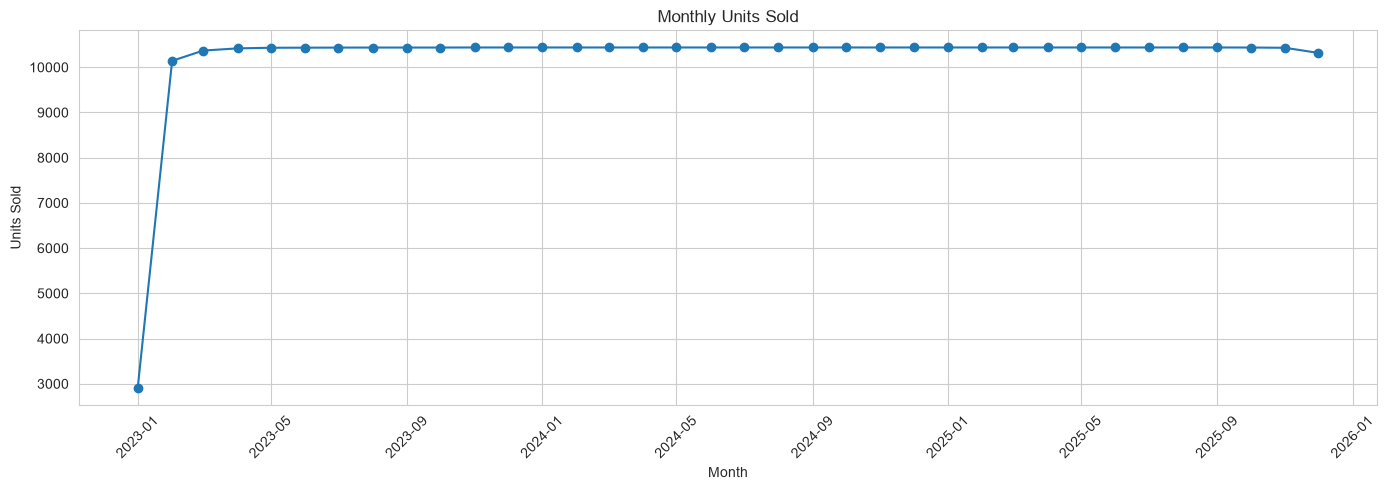

In [107]:
# Unit

plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index, monthly_sales["units"], marker="o")

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

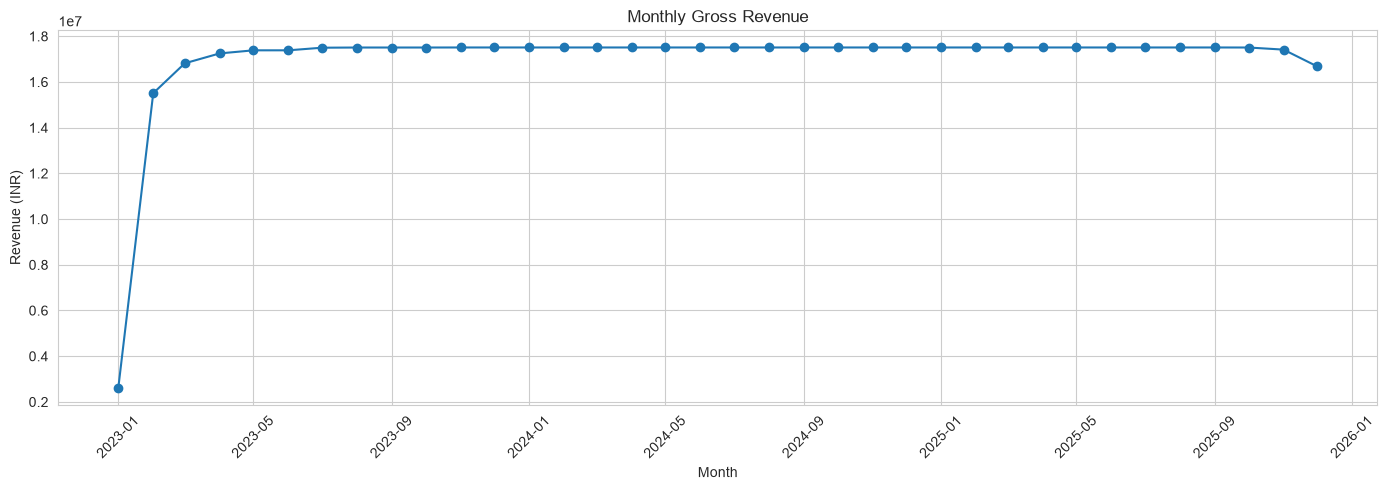

In [109]:
# Revenue

plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index, monthly_sales["revenue"], marker="o")

plt.title("Monthly Gross Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Stationarity test — ADF

In [110]:
# We'll use monthly units as the primary forecasting target.

units_series = monthly_sales["units"].asfreq("MS")

def adf_test(series, name="Series"):

    series = series.dropna()

    result = adfuller(series)

    print(f"ADF Test: {name}")
    print("-" * 40)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[4].items():
        print(f"   {key}: {value}")

    if result[1] < 0.05:
        print("\nResult: Stationary")
    else:
        print("\nResult: Non-stationary")


adf_test(units_series, "Monthly Units")

ADF Test: Monthly Units
----------------------------------------
ADF Statistic: 12.634458209386134
p-value: 1.0
Critical Values:
   1%: -3.7238633119999998
   5%: -2.98648896
   10%: -2.6328004

Result: Non-stationary


In [111]:
# If non-stationary, difference the series

units_diff = units_series.diff().dropna()

adf_test(units_diff, "Differenced Monthly Units")

ADF Test: Differenced Monthly Units
----------------------------------------
ADF Statistic: 9.612315049770894
p-value: 1.0
Critical Values:
   1%: -3.7377092158564813
   5%: -2.9922162731481485
   10%: -2.635746736111111

Result: Non-stationary


### ACF and PACF

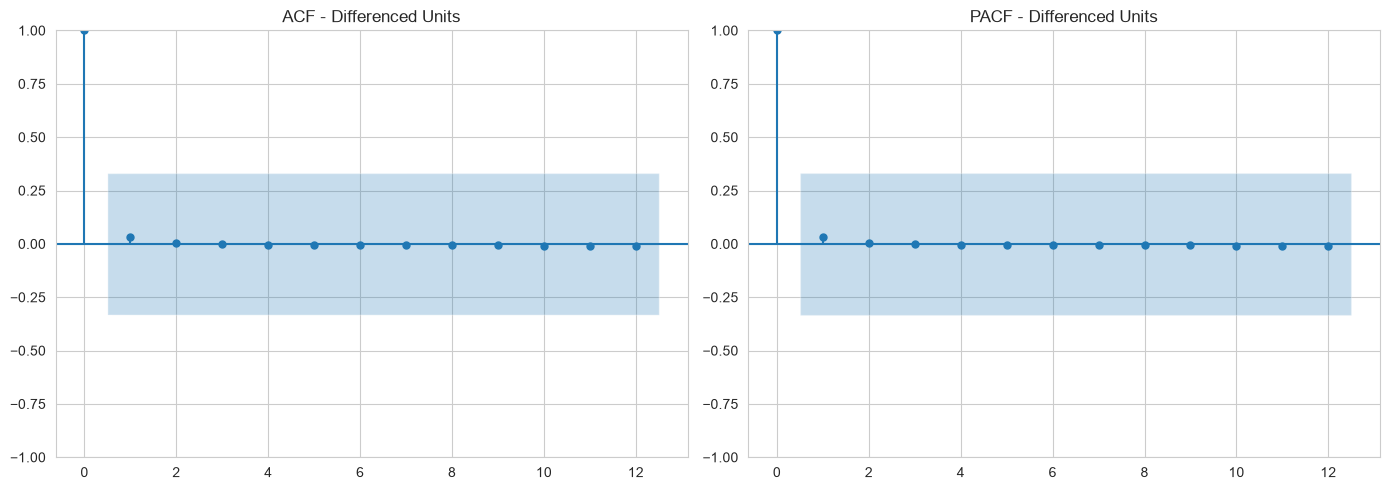

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    units_diff,
    lags=min(12, len(units_diff)//2),
    ax=axes[0]
)

plot_pacf(
    units_diff,
    lags=min(12, len(units_diff)//2),
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("ACF - Differenced Units")
axes[1].set_title("PACF - Differenced Units")

plt.tight_layout()
plt.show()

### Trend and seasonality decomposition

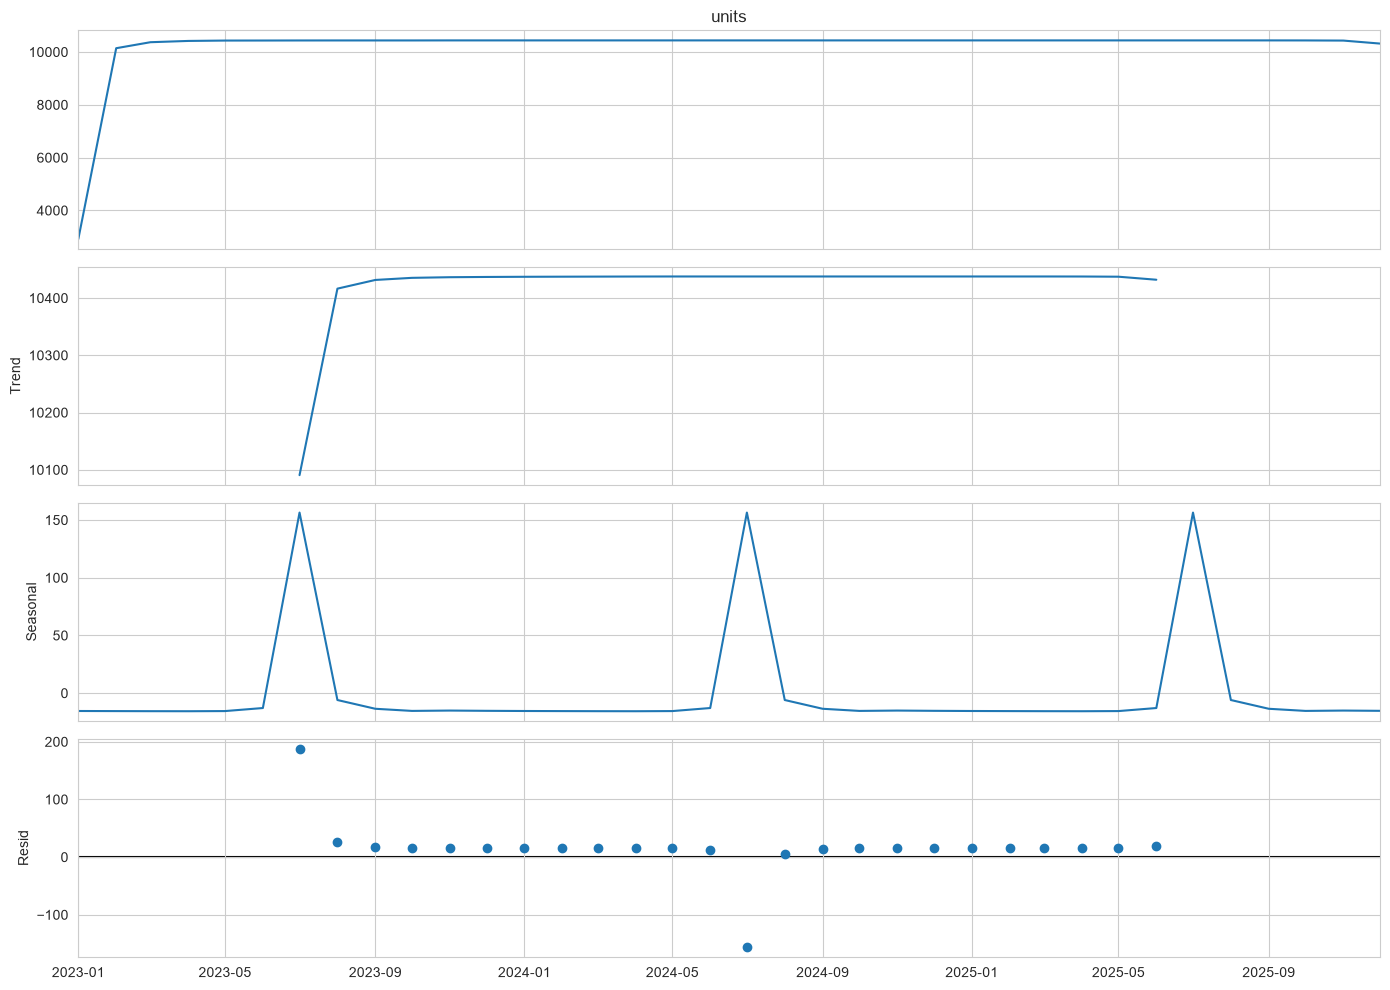

In [113]:
# Because we have monthly data, use a 12-month seasonal period.

decomposition = seasonal_decompose(units_series, model="additive", period=12)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### Train/test split

In [115]:
# We'll use the last 6 months as test data.

test_size = 6

train = units_series.iloc[:-test_size]
test = units_series.iloc[-test_size:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training period:
2023-01-01 00:00:00 to 2025-06-01 00:00:00

Testing period:
2025-07-01 00:00:00 to 2025-12-01 00:00:00


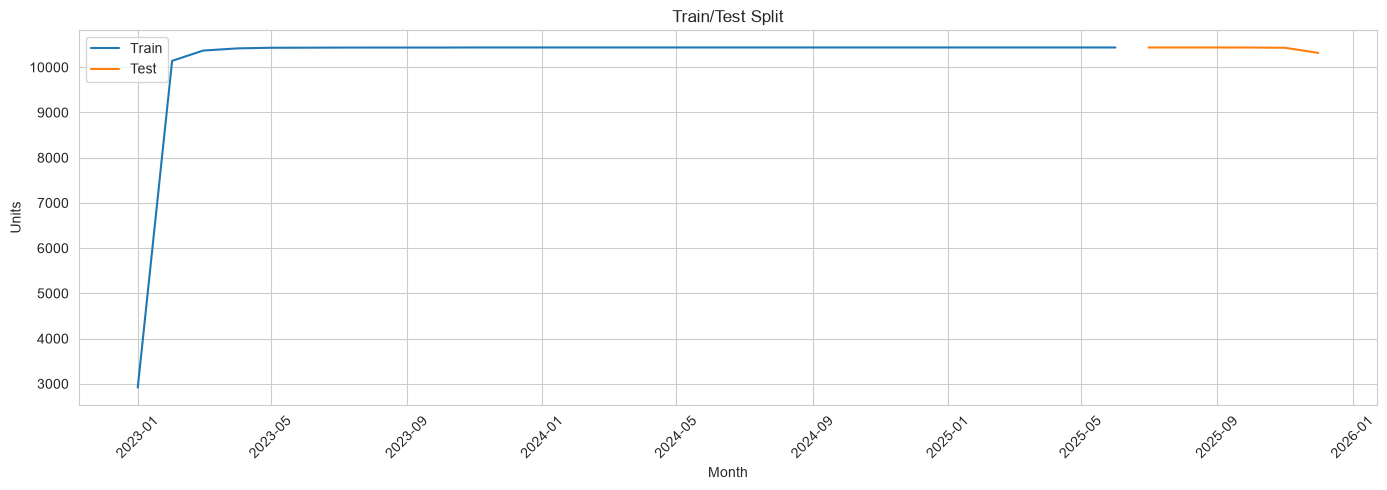

In [116]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Test")

plt.title("Train/Test Split")
plt.xlabel("Month")
plt.ylabel("Units")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Evaluation functions

In [117]:
def mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def rmse(y_true, y_pred):

    return np.sqrt(mean_squared_error(y_true,  y_pred))

### Naive baseline

In [118]:
# The naive model predicts that the next value will equal the last observed value.

naive_forecast = np.repeat(train.iloc[-1], len(test))

naive_mape = mape(test, naive_forecast)

naive_rmse = rmse(test, naive_forecast)

print("Naive Model")
print("MAPE:", round(naive_mape, 2), "%")
print("RMSE:", round(naive_rmse, 2))

Naive Model
MAPE: 0.21 %
RMSE: 49.06


### Moving Average baseline

In [119]:
window = 3

moving_average_forecast = []

history = list(train.values)

for i in range(len(test)):

    prediction = np.mean(history[-window:])

    moving_average_forecast.append(prediction)

    history.append(test.iloc[i])

moving_average_forecast = np.array(moving_average_forecast)

ma_mape = mape(test, moving_average_forecast)

ma_rmse = rmse(test, moving_average_forecast)

print("Moving Average Model")
print("MAPE:", round(ma_mape, 2), "%")
print("RMSE:", round(ma_rmse, 2))

Moving Average Model
MAPE: 0.2 %
RMSE: 47.95


### Holt-Winters model

In [120]:
holt_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

holt_fit = holt_model.fit(optimized=True)

holt_forecast = holt_fit.forecast(len(test))

holt_mape = mape(test, holt_forecast)

holt_rmse = rmse(test, holt_forecast)

print("Holt-Winters Model")
print("MAPE:", round(holt_mape, 2), "%")
print("RMSE:", round(holt_rmse, 2))

Holt-Winters Model
MAPE: 7.81 %
RMSE: 814.32


### SARIMA model

In [121]:
# A good starting configuration is: SARIMA(1,1,1)(1,1,1,12)

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_prediction = sarima_fit.get_forecast(steps=len(test))

sarima_forecast = sarima_prediction.predicted_mean

sarima_ci = sarima_prediction.conf_int()

sarima_mape = mape(test, sarima_forecast)

sarima_rmse = rmse(test, sarima_forecast)

print("SARIMA Model")
print("MAPE:", round(sarima_mape, 2), "%")
print("RMSE:", round(sarima_rmse, 2))

SARIMA Model
MAPE: 0.21 %
RMSE: 49.06


### Random Forest Model

In [122]:
N_LAGS = 3

# Build lag features: predict each month from the 3 months before it
train_lagged = pd.DataFrame({"y": train})
for i in range(1, N_LAGS + 1):
    train_lagged[f"lag_{i}"] = train_lagged["y"].shift(i)
train_lagged = train_lagged.dropna()

rf_ts = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_ts.fit(train_lagged.drop(columns="y"), train_lagged["y"])

# Recursive forecast: each prediction feeds the next step
history = list(train.values)
rf_forecast = []

for _ in range(len(test)):
    x = np.array(history[-N_LAGS:][::-1]).reshape(1, -1)
    yhat = rf_ts.predict(x)[0]
    rf_forecast.append(yhat)
    history.append(yhat)

rf_forecast = np.array(rf_forecast)

rf_mape = mape(test, rf_forecast)

rf_rmse = rmse(test, rf_forecast)

print("Random Forest Model")
print("MAPE:", round(rf_mape, 2), "%")
print("RMSE:", round(rf_rmse, 2))


Random Forest Model
MAPE: 0.21 %
RMSE: 49.06


### Compare all models

In [125]:
results = pd.DataFrame({
    "Model": ["Naive", "Moving Average", "Holt-Winters", "SARIMA", "Random Forest"],

    "MAPE": [naive_mape, ma_mape, holt_mape, sarima_mape, rf_mape],

    "RMSE": [naive_rmse, ma_rmse, holt_rmse, sarima_rmse, rf_rmse]
})

results = results.sort_values("RMSE").reset_index(drop=True)

results

,Model,MAPE,RMSE
0,Moving Average,0.201681,47.949210
1,Random Forest,0.206749,49.060276
2,Naive,0.206749,49.060276
3,SARIMA,0.206807,49.063524
4,Holt-Winters,7.808045,814.322102


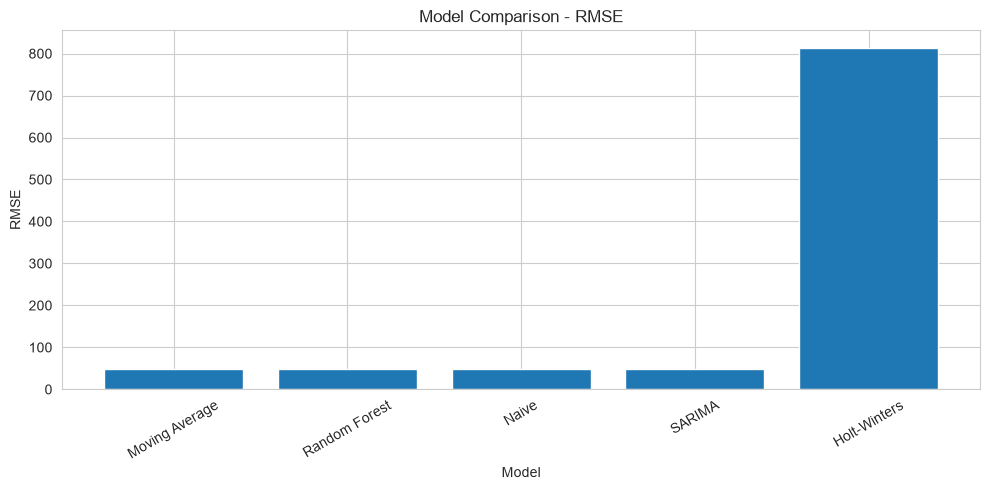

In [126]:
plt.figure(figsize=(10, 5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Compare actual vs predicted

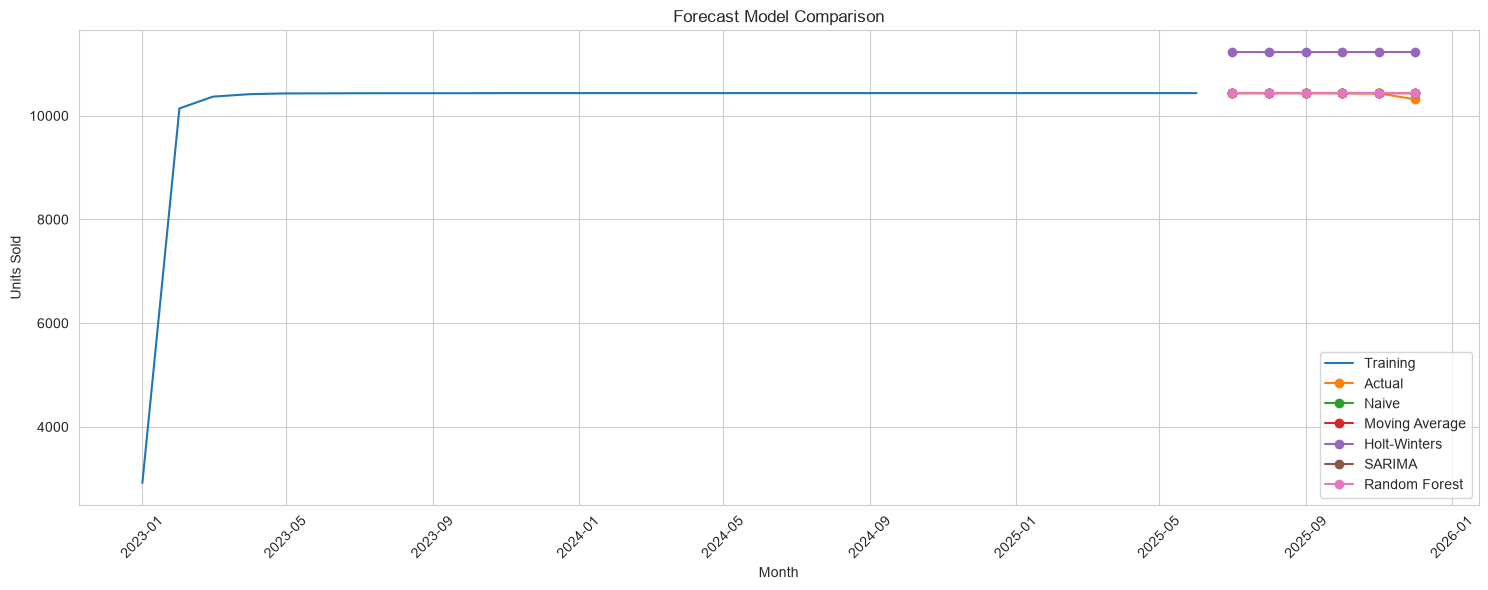

In [127]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, marker="o", label="Actual")

plt.plot(test.index, naive_forecast, marker="o", label="Naive")

plt.plot( test.index, moving_average_forecast, marker="o", label="Moving Average")

plt.plot(test.index, holt_forecast, marker="o", label="Holt-Winters")

plt.plot(test.index, sarima_forecast, marker="o", label="SARIMA")

plt.plot(test.index, rf_forecast, marker="o", label="Random Forest")

plt.title("Forecast Model Comparison")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### SARIMA confidence interval

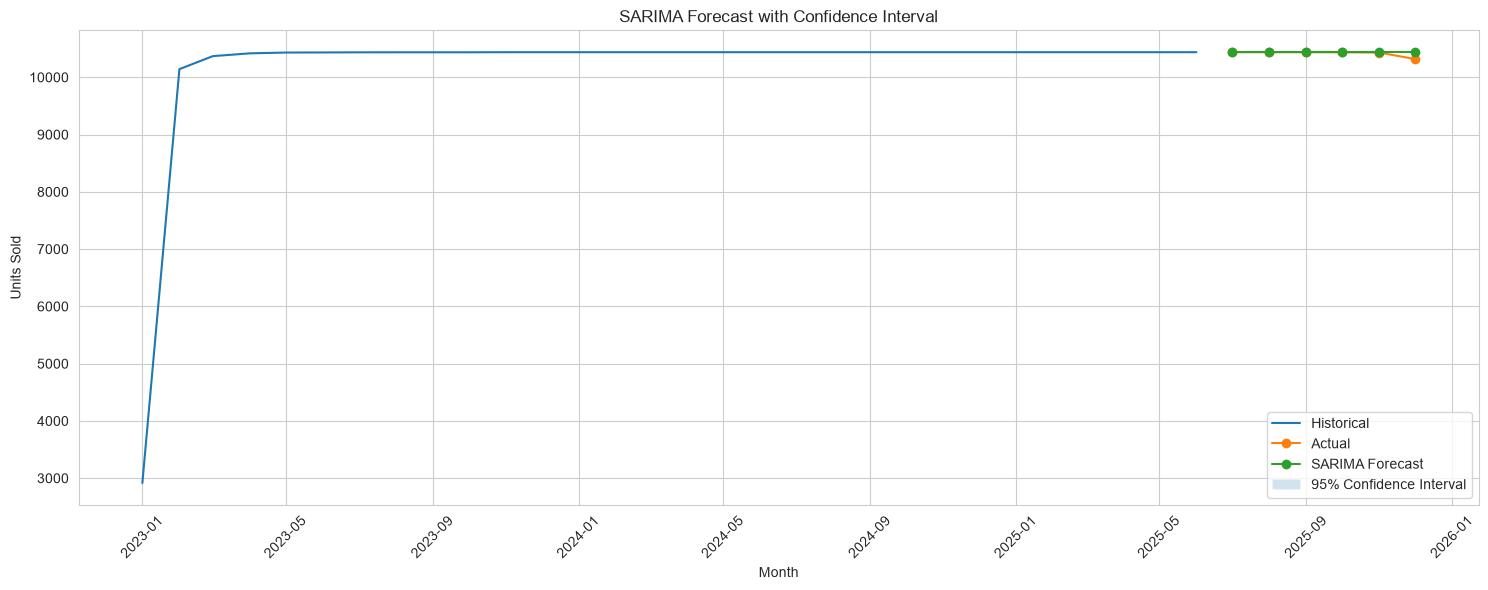

In [128]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train, label="Historical")

plt.plot(test.index, test, marker="o", label="Actual")

plt.plot(test.index, sarima_forecast, marker="o", label="SARIMA Forecast")

plt.fill_between(
    test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast with Confidence Interval")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Rolling-origin cross-validation

In [131]:
# This is important because you specifically wanted rolling-origin CV.

def rolling_origin_sarima(series, initial_train_size, horizon=1):

    predictions = []
    actuals = []

    for i in range(initial_train_size, len(series) - horizon + 1):

        train_data = series.iloc[:i]

        test_data = series.iloc[i:i + horizon]

        try:

            model = SARIMAX(
                train_data,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)

            forecast = fitted.forecast(horizon)

            predictions.extend(forecast.values)

            actuals.extend(test_data.values)

        except Exception as e:

            print("Error at iteration:", i, e)

    return (np.array(actuals), np.array(predictions))

In [132]:
initial_train_size = max(24, int(len(units_series) * 0.6))

cv_actual, cv_prediction = rolling_origin_sarima(
    units_series,
    initial_train_size=initial_train_size,
    horizon=1
)

cv_mape = mape(cv_actual, cv_prediction)

cv_rmse = rmse(cv_actual, cv_prediction)

print("Rolling-Origin SARIMA CV")
print("-------------------------")
print("MAPE:", round(cv_mape, 2), "%")
print("RMSE:", round(cv_rmse, 2))

Rolling-Origin SARIMA CV
-------------------------
MAPE: 0.08 %
RMSE: 26.75


### Plot rolling-origin CV

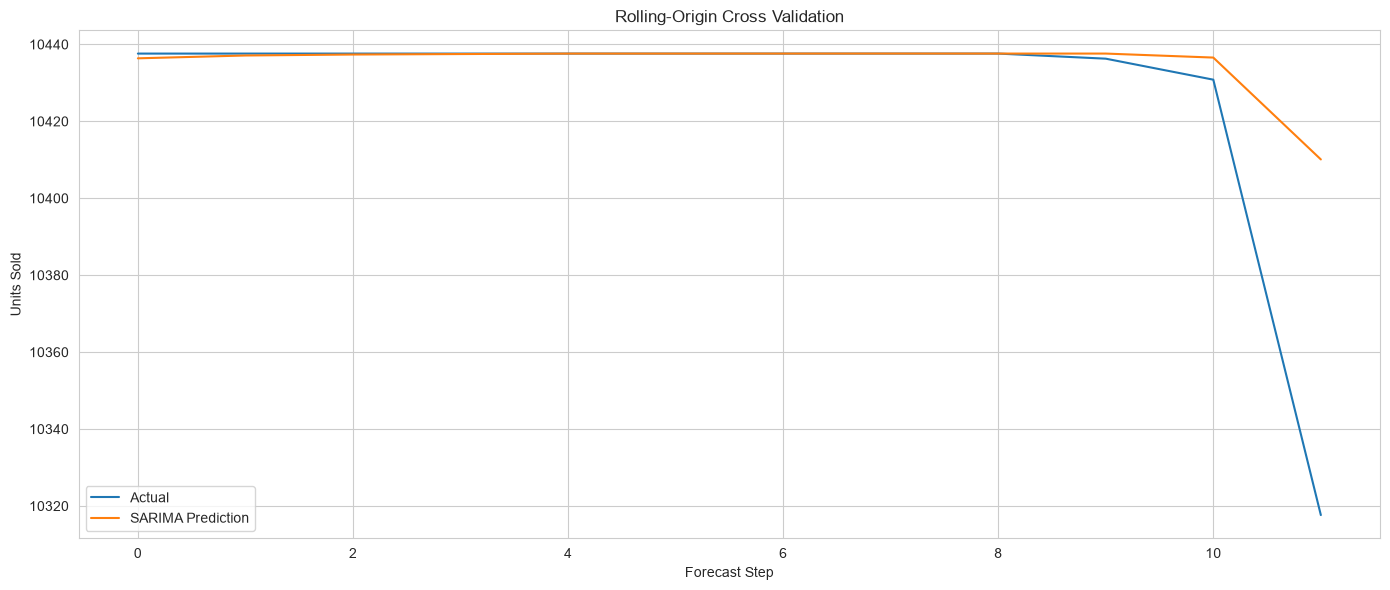

In [133]:
plt.figure(figsize=(14, 6))

plt.plot(cv_actual, label="Actual")

plt.plot(cv_prediction, label="SARIMA Prediction")

plt.title("Rolling-Origin Cross Validation")

plt.xlabel("Forecast Step")
plt.ylabel("Units Sold")

plt.legend()

plt.tight_layout()
plt.show()

### Train final SARIMA model on all data

In [134]:
# After evaluating the models, we train the final model using the entire historical dataset.

final_sarima = SARIMAX(
    units_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(disp=False)

In [135]:
# Forecast next 6 months

forecast_periods = 6

future_result = final_sarima_fit.get_forecast(steps=forecast_periods)

future_forecast = future_result.predicted_mean

future_ci = future_result.conf_int()

print("Next 6 Months Forecast:")
print(future_forecast)

Next 6 Months Forecast:
2026-01-01    8.833060e+03
2026-02-01   -1.007763e+04
2026-03-01   -2.509711e+05
2026-04-01   -3.319603e+06
2026-05-01   -4.240950e+07
2026-06-01   -5.403577e+08
Freq: MS, Name: predicted_mean, dtype: float64


### Final forecast plot

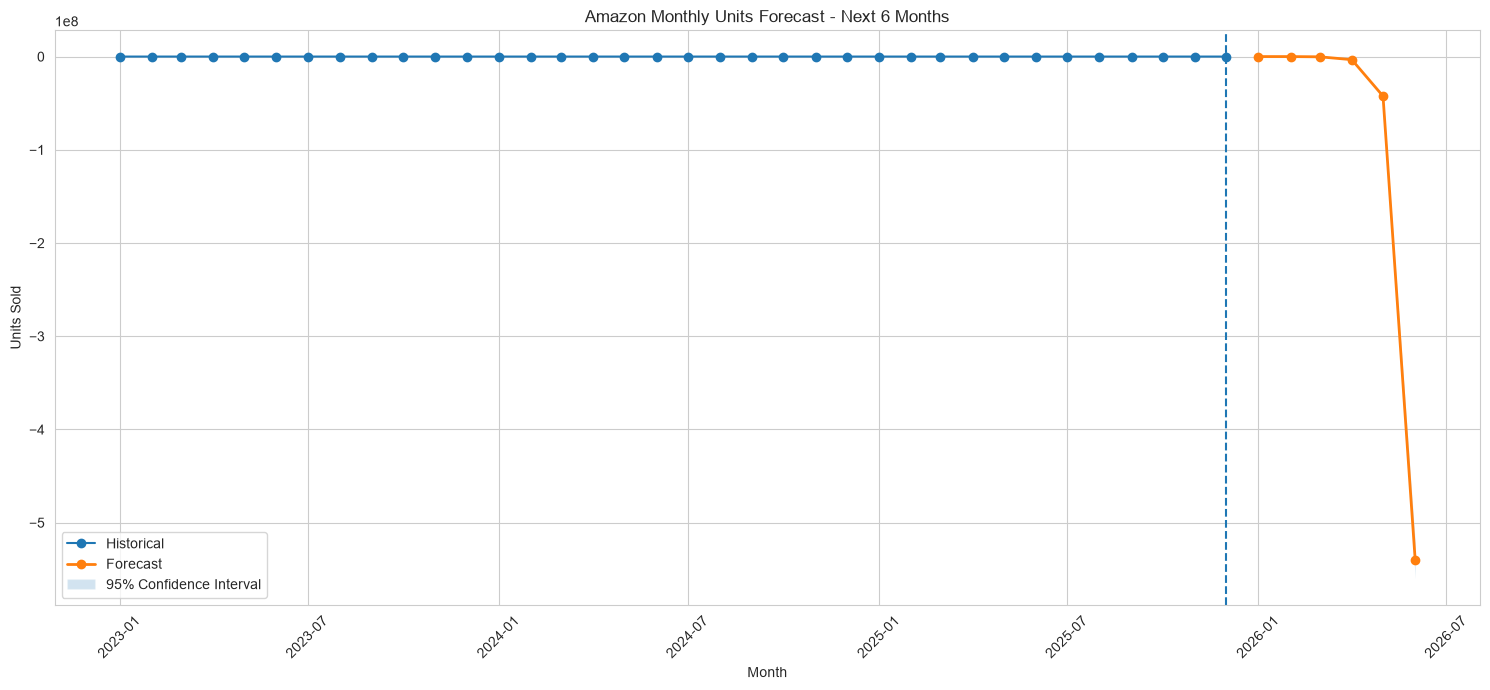

In [136]:
plt.figure(figsize=(15, 7))

plt.plot(
    units_series.index,
    units_series,
    marker="o",
    label="Historical"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    future_forecast.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    units_series.index[-1],
    linestyle="--"
)

plt.title(
    "Amazon Monthly Units Forecast - Next 6 Months"
)

plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Create final forecast table

In [137]:
forecast_table = pd.DataFrame({
    "Month": future_forecast.index,
    "Forecast_Units": future_forecast.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values
})

forecast_table["Forecast_Units"] = (forecast_table["Forecast_Units"].clip(lower=0))

forecast_table["Lower_CI"] = (forecast_table["Lower_CI"].clip(lower=0))

forecast_table["Upper_CI"] = (forecast_table["Upper_CI"].clip(lower=0))

forecast_table

,Month,Forecast_Units,Lower_CI,Upper_CI
0,2026-01-01,8833.060303,8783.27766,8882.842946
1,2026-02-01,0.000000,0.00000,0.000000
2,2026-03-01,0.000000,0.00000,0.000000
3,2026-04-01,0.000000,0.00000,0.000000
4,2026-05-01,0.000000,0.00000,0.000000
5,2026-06-01,0.000000,0.00000,0.000000
